Prediction: 0


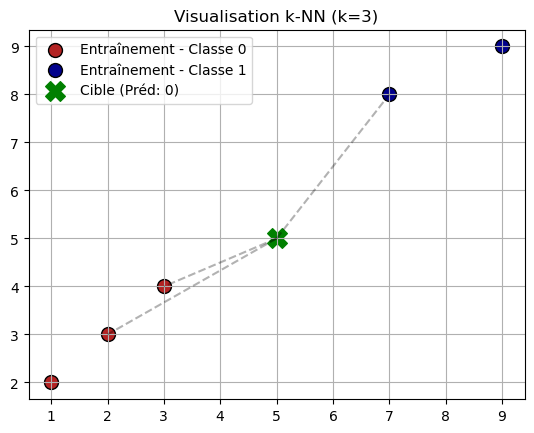

In [11]:
#Code python d'algorithme de KNN : classification du point cible

import numpy as np   # une bibliothèque pour faire des calculs mathématiques
import matplotlib.pyplot as plt    # une bibliothèque qui dessine les graphes
from collections import Counter  #Un outil qui permet de compter facilement les éléments dans une liste

# dataset
X = np.array([[1,2], [2,3], [3,4], [7,8], [9,9]])  # les positions (X1, X2)
y = np.array([0,0,0,1,1])      #les classes (0 ou 1)

x_cible = np.array([5,5])  # point à prédire est ce qu'il est dans la classe 0 ou 1

def distance(a, b):   # la distance euclidienne qui calcule l'espace droite entre 2 points
    return np.sqrt(np.sum((a - b)**2))

distances = [distance(x_cible, xi) for xi in X] # calcule la distance entre notre la point cible et chaque point du dataset
k = 3   # les 3 voisins les plus proches
k_indices = np.argsort(distances)[:k]  # trie les distances du plus petit au plus grand sous forme indices
k_labels = [y[i] for i in k_indices]   # On regarde les classes (0 ou 1) de ces 3 voisins les plus proches
prediction = Counter(k_labels).most_common(1)[0][0]  # compte les votes
print("Prediction:", prediction)
#La Visualisation
# afficher la classe 0 en rouge
plt.scatter(X[y == 0, 0], X[y == 0, 1], color='firebrick', s=100, edgecolor='black', label='Entraînement - Classe 0')
# afficher la classe 1 en bleu
plt.scatter(X[y == 1, 0], X[y == 1, 1], color='darkblue', s=100, edgecolor='black', label='Entraînement - Classe 1')
plt.scatter(x_cible[0], x_cible[1], c='green', s=200, marker='X', label=f'Cible (Préd: {prediction})')  # affiche le point à prédire 
for i in k_indices:   # relie la cible aux voisins pour comprendre le choix
    plt.plot([x_cible[0], X[i,0]], [x_cible[1], X[i,1]], 'k--', alpha=0.3)

plt.title(f"Visualisation k-NN (k={k})")
plt.legend()
plt.grid(True)
plt.show()

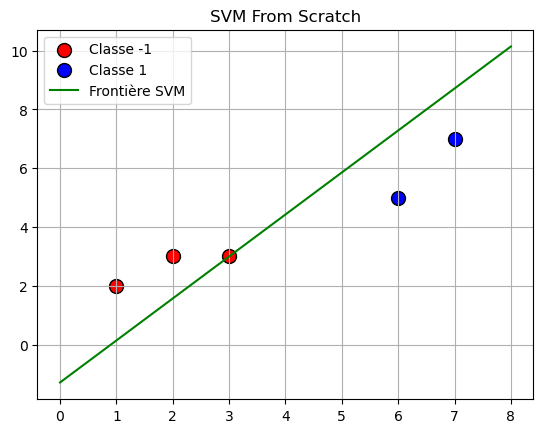

In [22]:
# Algorithme SVM : Frontière de décision linéaire

X = np.array([[1,2], [2,3], [3,3], [6,5], [7,7]]) 
y = np.array([-1, -1, -1, 1, 1])   # On utilise -1 et 1 pour les classes  
x_cible = np.array([5, 5])  # Point cible à prédire
w = np.array([0.0, 0.0]) # le vecteur qui donne l'angle de la ligne
b = 0.0                  #Bias c'est le décalage de la ligne par rapport à l'origine
t = 0.1   # c'est la force de la correction. Si on fait une erreur on bouge la ligne de 0.1 unité
# ENTRAÎNEMENT 
for _ in range(100):
    for i in range(len(X)):
        if y[i] * (np.dot(X[i], w) + b) <= 0:  #Si le résultat est négatif ou nul cela signifie que le point est du mauvais côté de la ligne
            w += t * y[i] * X[i]  #Si le point est mal classé on ajuste w et b
            b += t * y[i]
#VISUALISATION
plt.scatter(X[y == -1, 0], X[y == -1, 1], color='red', s=100, edgecolor='k', label='Classe -1 ')
plt.scatter(X[y == 1, 0], X[y == 1, 1], color='blue', s=100, edgecolor='k', label='Classe 1 ')
y_plot = -(w[0] * x_plot + b) / w[1]   # Transforme l'équation mathématique (w*x + b = 0) en coordonnées (x, y) pour dessiner la ligne sur le graphique

plt.plot(x_plot, y_plot, 'g-', label="Frontière SVM")
plt.title("SVM From Scratch")
plt.legend()
plt.grid(True)
plt.show()